In [1]:
# Code by Yug Saini
# Project Submitted under Guidance from Dr Rishi Asthana, Course : Linear Algebra and Differential Equations
# Image compression using Principal Component anaylsis
# Date : 11 Nov 2025

In [57]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [58]:
img = cv2.cvtColor(cv2.imread("red_dice.jpg"), cv2.COLOR_BGR2RGB)

In [59]:
img.shape

(1336, 2546, 3)

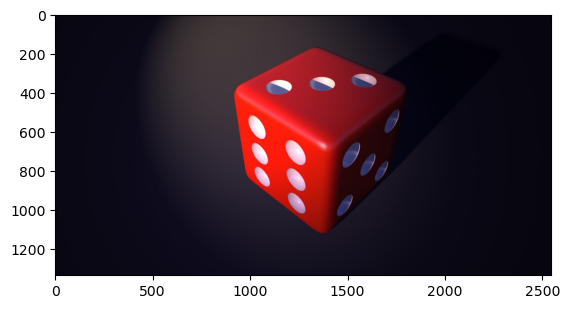

In [60]:
plt.imshow(img)

In [61]:
r, g, b = cv2.split(img)

In [62]:
r, g, b = r/255, g/255, b/255 # normalising them between 0 and 1


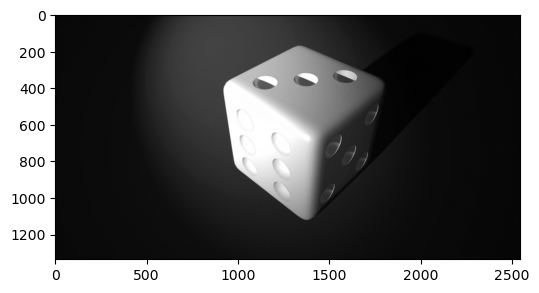

In [63]:
plt.figure(figsize = (6,10))
plt.imshow(r,cmap='gray')
# plt.text(x = 2900, y = 900, s = "Here the white color means, on that region RED color is Present there")
# plt.text(x = 2900, y = 1000, s = "(The brighter the white, more will be the intensity of RED color in the orignal image)")
plt.show()

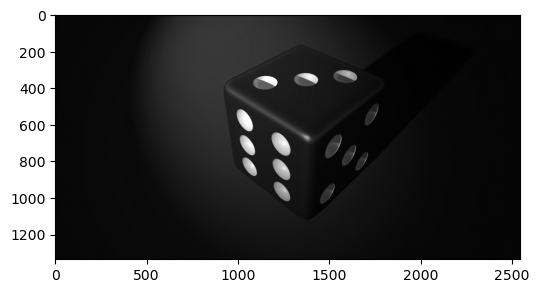

In [64]:
plt.figure(figsize = (6,10))
plt.imshow(g,cmap = 'gray')
# plt.text(x = 2900, y = 900, s = "Here the white color means, on that region GREEN color is Present there")
# plt.text(x = 2900, y = 1000, s = "(The brighter the white, more will be the intensity of GREEN color in the orignal image)")
plt.show();

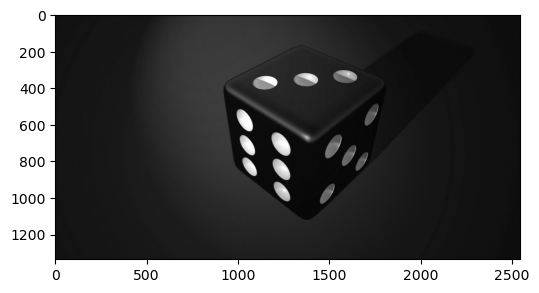

In [65]:
plt.figure(figsize = (6,10))
plt.imshow(b, cmap= 'gray')
# plt.text(x = 2700, y = 900, s = "Similarly, here we can see the brightness,")
# plt.text(x = 2700, y = 1000, s = "From this we can conclude that our image must be blue since it seems dominant in this plot")
plt.show()

In [66]:
r.shape
# previous 

(1336, 2546)

In [84]:
pca_components = 25
pca_r =PCA(n_components = pca_components)
reduced_r = pca_r.fit_transform(r)

In [85]:
reduced_r.shape

(1336, 25)

In [86]:
# similarly using pca on green
pca_g =PCA(n_components = pca_components)
reduced_g = pca_g.fit_transform(g)
 # and blue
pca_b =PCA(n_components = pca_components)
reduced_b = pca_b.fit_transform(b)

In [87]:
combined = np.array([reduced_r, reduced_g, reduced_b])
combined.shape

(3, 1336, 25)

In [88]:
reconstructed_r = pca_r.inverse_transform(reduced_r)
reconstructed_g = pca_g.inverse_transform(reduced_g)
reconstructed_b = pca_b.inverse_transform(reduced_b)

In [89]:
img_reconstructed = (cv2.merge((reconstructed_r,reconstructed_g,reconstructed_b)))
img_reconstructed.shape
# this has the orignal shape

(1336, 2546, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16488377567547252..1.1540069203837067].


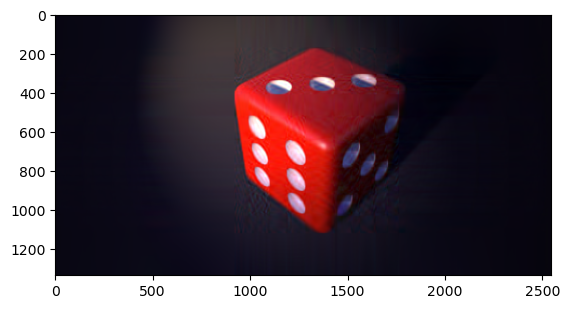

In [90]:
plt.imshow(img_reconstructed)

In [82]:
def pca_im(img, k):
    img = img/255.0
    r, g, b = cv2.split(img)
    pca_components = k
    pca_r =PCA(n_components = pca_components)
    reduced_r = pca_r.fit_transform(r)
    pca_g =PCA(n_components = pca_components)
    reduced_g = pca_g.fit_transform(g)
    pca_b =PCA(n_components = pca_components)
    reduced_b = pca_b.fit_transform(b)
    reconstructed_r = pca_r.inverse_transform(reduced_r)
    reconstructed_g = pca_g.inverse_transform(reduced_g)
    reconstructed_b = pca_b.inverse_transform(reduced_b)
    img_reconstructed = (cv2.merge((reconstructed_r,reconstructed_g,reconstructed_b)))
    return img_reconstructed

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10513675962834096..1.1158987771958844].


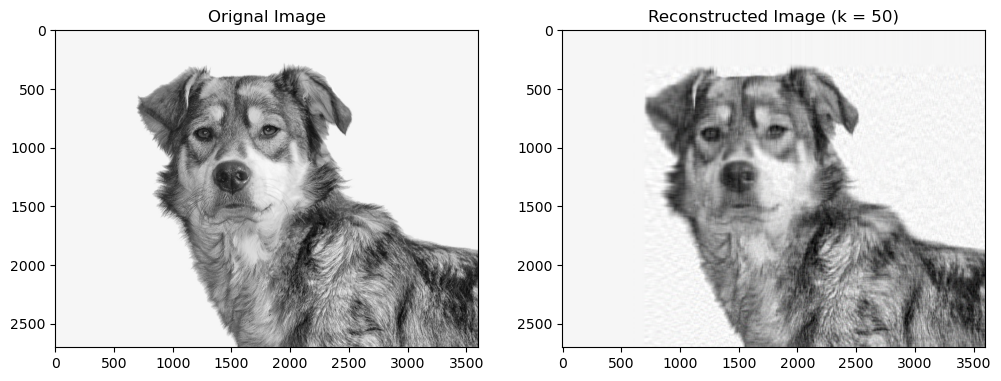

In [83]:
img2 = cv2.cvtColor(cv2.imread("dog.jpg"), cv2.COLOR_BGR2RGB)
im2_reconstructed = pca_im(img2,50)
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img2)
plt.title("Orignal Image")

plt.subplot(1,2,2)
plt.imshow(im2_reconstructed)
plt.title("Reconstructed Image (k = 50)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14754672800480295..1.131522851890005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15954751975409565..1.1186621516705773].


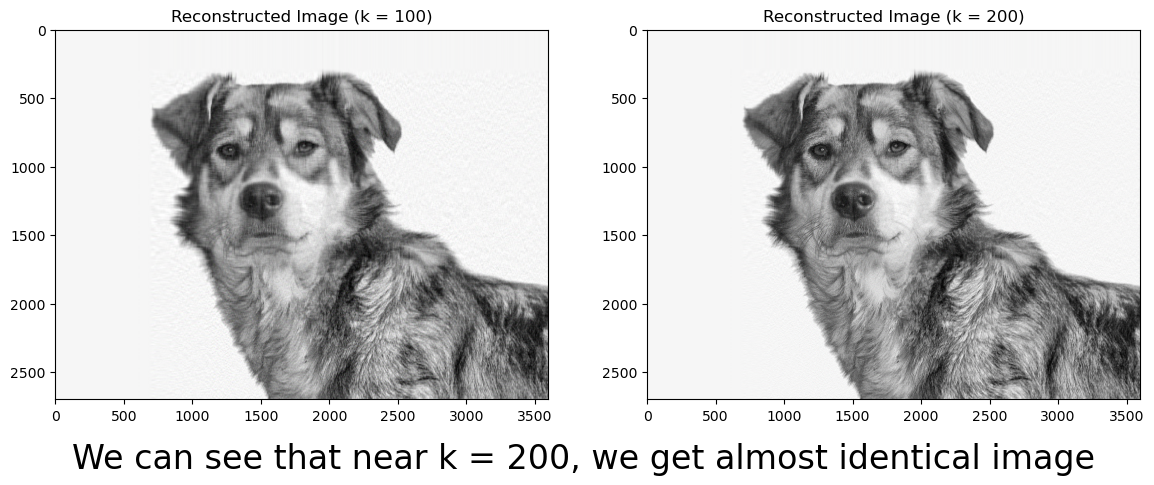

In [41]:
im2_reconstructed_100 = pca_im(img2,100)
im2_reconstructed_200 = pca_im(img2,200)
plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.imshow(im2_reconstructed_100)
plt.title("Reconstructed Image (k = 100)")

plt.subplot(1,2,2)
plt.imshow(im2_reconstructed_200)
plt.title("Reconstructed Image (k = 200)")
plt.text(x = -4200, y = 3200,fontsize = 24 ,s= "We can see that near k = 200, we get almost identical image")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1525367274242725..1.0614347301022864].


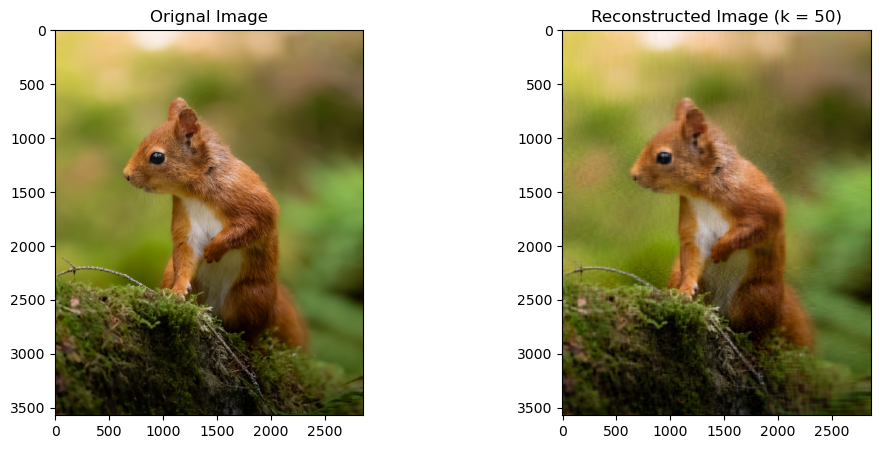

In [42]:
# lets try on somehting more colourfull
img3 = cv2.cvtColor(cv2.imread("squirrel.jpg"), cv2.COLOR_BGR2RGB)
im3_reconstructed = pca_im(img3,50)
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img3)
plt.title("Orignal Image")

plt.subplot(1,2,2)
plt.imshow(im3_reconstructed)
plt.title("Reconstructed Image (k = 50)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2253456220894511..1.256475819106573].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2105990458089121..1.2430362515997049].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2148242960600365..1.2051378949263158].


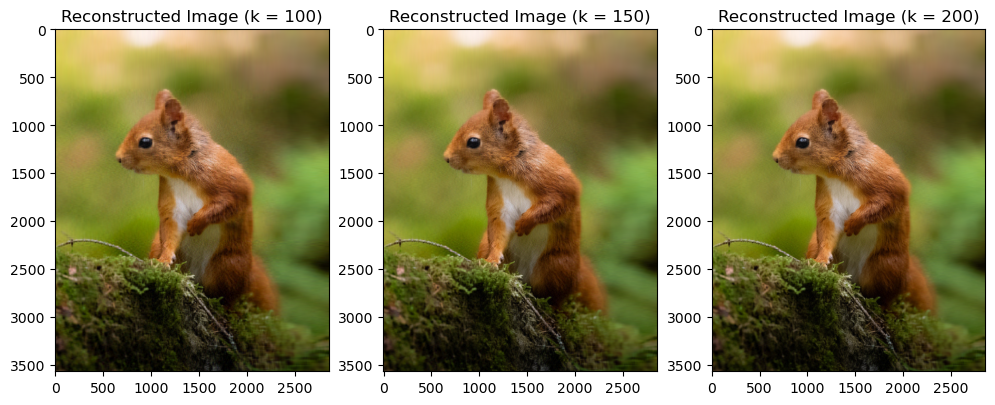

In [47]:
im3_reconstructed_100 = pca_im(img3,100)
im3_reconstructed_150 = pca_im(img3,150)
im3_reconstructed_200 = pca_im(img3,200)
plt.figure(figsize = (12,5))
plt.subplot(1,3,1)
plt.imshow(im3_reconstructed_100)
plt.title("Reconstructed Image (k = 100)")

plt.subplot(1,3,2)
plt.imshow(im3_reconstructed_150)
plt.title("Reconstructed Image (k = 150)")

plt.subplot(1,3,3)
plt.imshow(im3_reconstructed_200)
plt.title("Reconstructed Image (k = 200)")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4629385395549568..1.3594251188362398].


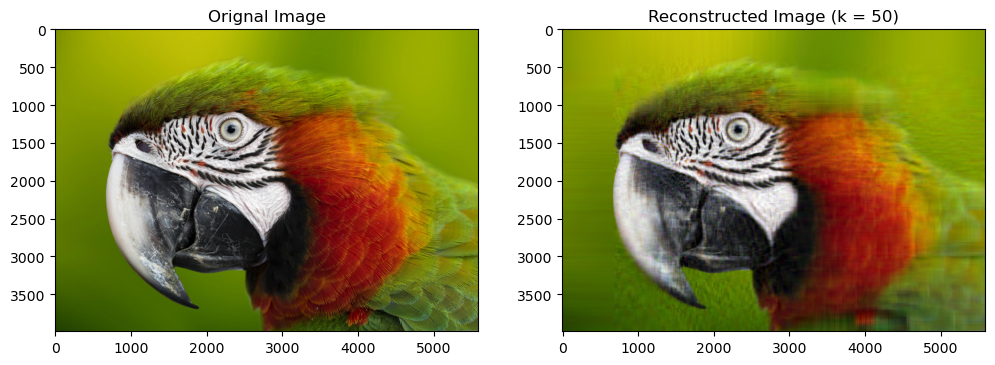

In [53]:
# lets try on somehting more colourfull
img4 = cv2.cvtColor(cv2.imread("macawjpg.jpg"), cv2.COLOR_BGR2RGB)
im4_reconstructed = pca_im(img4,50)
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img4)
plt.title("Orignal Image")

plt.subplot(1,2,2)
plt.imshow(im4_reconstructed)
plt.title("Reconstructed Image (k = 50)")
plt.show()

In [54]:
im4_reconstructed_100 = pca_im(img4,100)
im4_reconstructed_150 = pca_im(img4,150)
im4_reconstructed_200 = pca_im(img4,200)
plt.figure(figsize = (12,5))
plt.subplot(1,3,1)
plt.imshow(im4_reconstructed_100)
plt.title("Reconstructed Image (k = 100)")

plt.subplot(1,3,2)
plt.imshow(im4_reconstructed_150)
plt.title("Reconstructed Image (k = 150)")

plt.subplot(1,3,3)
plt.imshow(im4_reconstructed_200)
plt.title("Reconstructed Image (k = 200)")
plt.show()

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\alloc.cpp:73: error: (-4:Insufficient memory) Failed to allocate 535240992 bytes in function 'cv::OutOfMemoryError'
